In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from huggingface_hub import login
from keras.utils import pad_sequences
from keras.src.legacy.preprocessing.text import Tokenizer
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU
from keras.layers import Bidirectional
from sklearn.metrics import confusion_matrix
import os
import pickle


c:\Emotion Prediction\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()

login(token=os.getenv("HF_TOKEN"))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
emotion_dataset= load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']
label_names = emotion_dataset['train'].features['label'].names


<Axes: xlabel='label', ylabel='count'>

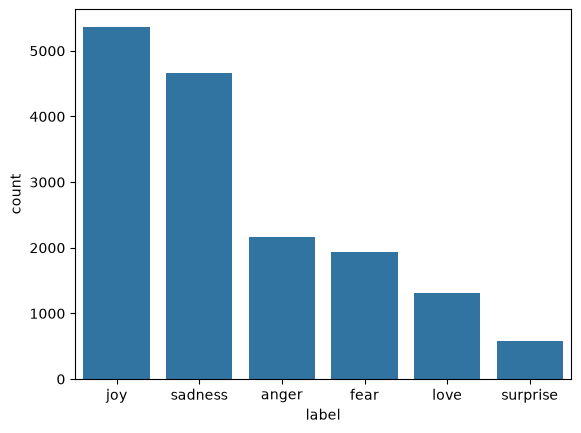

In [4]:
df_train=pd.DataFrame(
    {
        'text':train_text,
        'label':[label_names[i] for i in train_label]
    }
)
df_test=pd.DataFrame(
    {
        'text':test_text,
        'label':[label_names[i] for i in test_label]
    }
)
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)


In [5]:
max_words=10000
tokenizer=Tokenizer(num_words=max_words,oov_token='<ukn>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence=tokenizer.texts_to_sequences(df_train['text'])
test_sequence=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence=pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence=pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

train_labels=np.array(train_label)
test_labels=np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f"Vocabulary size :{len(tokenizer.word_index)}")
print(f"Max Sentence length :{padded_train_sequence.shape[1]}")


Vocabulary size :15213
Max Sentence length :50


In [6]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_dic=dict(enumerate(class_weights))


In [7]:
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


 ### Model 1 — Simple RNN

In [8]:
rnn_models= Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')]
)
rnn_models.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

rnn_models.fit(
    padded_train_sequence,
    train_labels,
    validation_data= (padded_test_sequence,test_labels),
    epochs= 20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping]
)
rnn_loss, rnn_accuracy = rnn_models.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")


Epoch 1/20


c:\Emotion Prediction\env\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.1593 - loss: 1.9527 - val_accuracy: 0.1625 - val_loss: 1.7857
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.1552 - loss: 1.8191 - val_accuracy: 0.1910 - val_loss: 1.7699
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.1506 - loss: 1.7969 - val_accuracy: 0.1465 - val_loss: 1.7843
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.1484 - loss: 1.7831 - val_accuracy: 0.1285 - val_loss: 1.7915
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.1461 - loss: 1.7779 - val_accuracy: 0.1250 - val_loss: 1.7986
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1910 - loss: 1.7699
RNN Loss: 1.7698546648025513
RNN Accuracy: 0.19099999964237213


 ### Model 2 — LSTM

In [9]:
lstm_models= Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    LSTM(units=128,return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')]
)
lstm_models.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

lstm_models.fit(
    padded_train_sequence,
    train_labels,
    validation_data= (padded_test_sequence,test_labels),
    epochs= 20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_models.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.1548 - loss: 1.7951 - val_accuracy: 0.0330 - val_loss: 1.8136
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1512 - loss: 1.7940 - val_accuracy: 0.0375 - val_loss: 1.8006
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1724 - loss: 1.7884 - val_accuracy: 0.0860 - val_loss: 1.8197
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.1836 - loss: 1.7124 - val_accuracy: 0.2760 - val_loss: 1.6781
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.3208 - loss: 1.4628 - val_accuracy: 0.3725 - val_loss: 1.3746
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.5261 - loss: 1.0274 - val_accuracy: 0.5845 - val_loss: 1.0766
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.7559 - loss: 0.6459 - val_accuracy: 0.8285 - val_loss: 0.6160
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.8523 - loss: 0.4380 - 

 ### Model 3 — GRU

In [10]:
gru_models= Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    GRU(units=128,return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')]
)
gru_models.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

gru_models.fit(
    padded_train_sequence,
    train_labels,
    validation_data= (padded_test_sequence,test_labels),
    epochs= 20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_models.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.1423 - loss: 1.7959 - val_accuracy: 0.1120 - val_loss: 1.7739
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.1696 - loss: 1.7951 - val_accuracy: 0.0795 - val_loss: 1.8149
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1616 - loss: 1.7941 - val_accuracy: 0.2895 - val_loss: 1.7798
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1702 - loss: 1.7931 - val_accuracy: 0.1125 - val_loss: 1.7924
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1120 - loss: 1.7739
GRU Loss: 1.7739187479019165
GRU Accuracy: 0.1120000034570694


In [11]:
result_df=pd.DataFrame({
    'Model':['Rnn','LSTM','GRU'],
    'Test loss':[rnn_loss,lstm_loss,gru_loss],
    'Test Accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy]
})


 ### Model 4 — BiGRU

In [12]:
BiGRU =Sequential([
    Embedding (input_dim= max_words, output_dim=300, input_length = 50),
    Bidirectional (GRU(128, return_sequences=True)),
    Dropout (0.5),
    Bidirectional (GRU(64)),
    Dropout (0.5),
    Dense(num_classes, activation='softmax')]
)
BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics= ['accuracy'] )

BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data= (padded_test_sequence,test_labels),
    epochs= 20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping]
)

BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {BiGRU_loss}")
print(f"GRU Accuracy: {BiGRU_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.5782 - loss: 1.0248 - val_accuracy: 0.9045 - val_loss: 0.2915
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9133 - loss: 0.2477 - val_accuracy: 0.9145 - val_loss: 0.2330
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9431 - loss: 0.1549 - val_accuracy: 0.9155 - val_loss: 0.2415
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9580 - loss: 0.1177 - val_accuracy: 0.9110 - val_loss: 0.2728
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9673 - loss: 0.0914 - val_accuracy: 0.9155 - val_loss: 0.2687
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9145 - loss: 0.2330
GRU Loss: 0.233024463057518
GRU Accuracy: 0.9144999980926514


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


<Axes: >

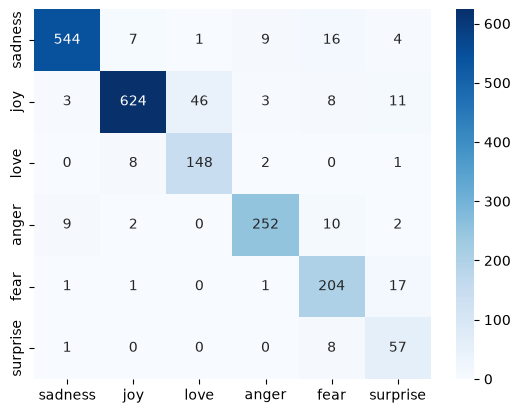

In [13]:
BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)
sns.heatmap(confusion_matrix(test_label,BiGRU_predictions),annot=True,fmt='d',cmap='Blues', xticklabels=label_names, yticklabels=label_names)


In [14]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]
sample_sequences=tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences=pad_sequences (sample_sequences, maxlen=50, padding='post', truncating='post')
sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [16]:
model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai
#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))
#Save the tokenizer
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file: pickle.dump(tokenizer, file)